In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [19]:
df = pd.read_csv('advertising - advertising.csv', names=['TV','Radio','Newspaper','Sales'], header=0)
df.head(5)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [20]:
# Cho biet kich thuoc cua du lieu
print(df.shape)

(200, 4)


In [21]:
# Cho biet thong tin cua du lieu
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None


In [22]:
# in ra bang thong ke mo ta
print(df.describe())

               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


In [23]:
# trong du lieu nay co du lieu null hay khong
print(df.isnull().sum())

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [24]:
# Xem du lieu cua cot TV
print(df['TV'])

0      230.1
1       44.5
2       17.2
3      151.5
4      180.8
       ...  
195     38.2
196     94.2
197    177.0
198    283.6
199    232.1
Name: TV, Length: 200, dtype: float64


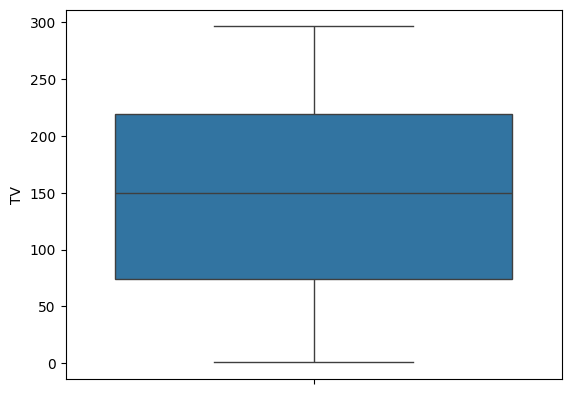

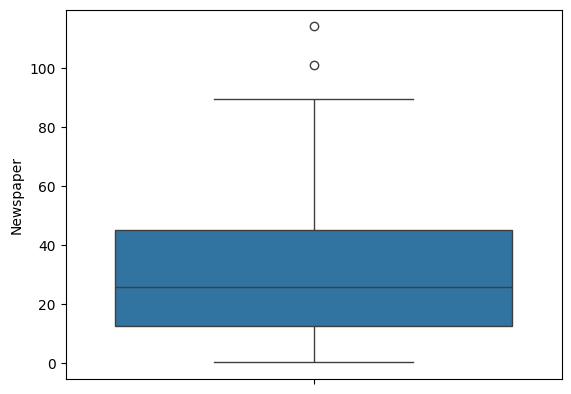

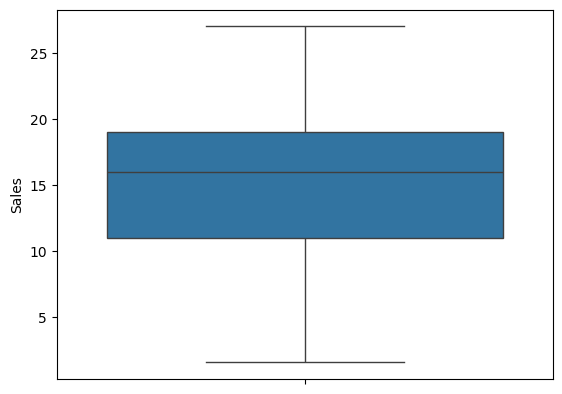

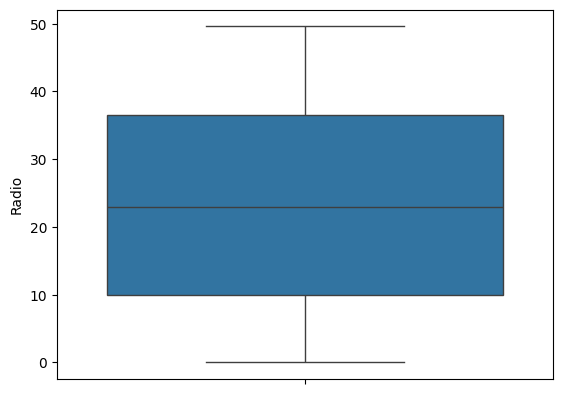

In [31]:
# Kiem tra ngoai le TV
sns.boxplot(df['TV'])
plt.show()
# Kiem tra ngoai le Newspaper
sns.boxplot(df['Newspaper'])
plt.show()
# Kiem tra ngoai le Sales
sns.boxplot(df['Sales'])
plt.show()
# Kiem tra ngoai le Radio
sns.boxplot(df['Radio'])
plt.show()

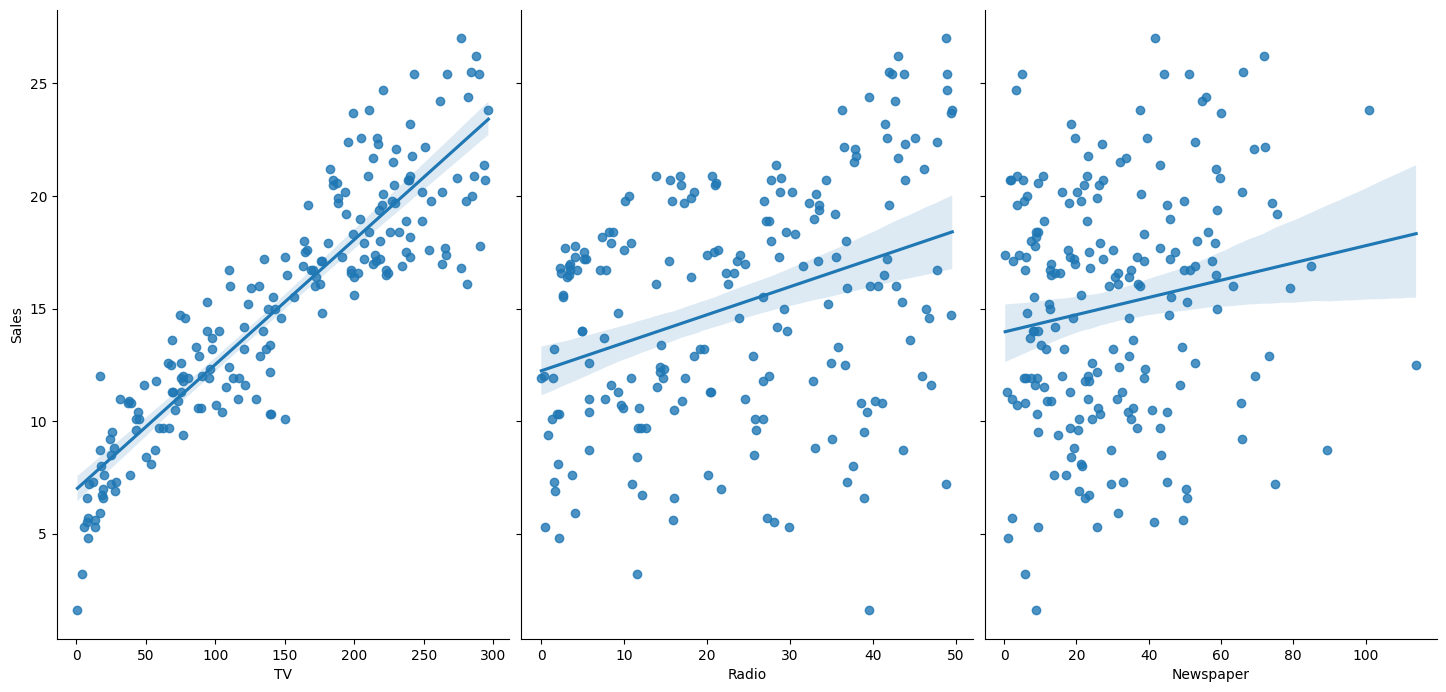

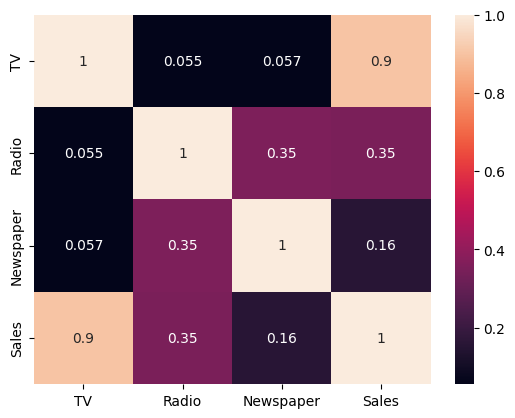

In [37]:
# Ve bieu do cho biet su tuong quan cua Sales va cac thuoc tinh TV, Radio, Newspaper
sns.pairplot(df, x_vars=['TV','Radio','Newspaper'], y_vars='Sales', height=7, aspect=0.7, kind='reg')
plt.show()
# Lien quan toi bien nao nhieu nhat voi Sales 
# Ket luan: TV co moi quan he tot nhat voi Sales
# Ve heatmap cua TV va Sales
sns.heatmap(df.corr(), annot=True)
plt.show()


In [39]:
# Cho biet su anh huong cua Sales den TV (cai nao la bien phu thuoc, cai nao la biet doc lap)
# Sales la bien phu thuoc, TV la bien doc lap
x = sm.add_constant(df[['TV']].values)
y = df['Sales'].values
model = sm.OLS(y, x).fit()
print(model.summary())
# Viet phuong trinh hoi quy
print('Sales = 6.9748 +  0.0555*TV')



                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.812
Model:                            OLS   Adj. R-squared:                  0.811
Method:                 Least Squares   F-statistic:                     856.2
Date:                Thu, 26 Sep 2024   Prob (F-statistic):           7.93e-74
Time:                        14:13:53   Log-Likelihood:                -448.99
No. Observations:                 200   AIC:                             902.0
Df Residuals:                     198   BIC:                             908.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.9748      0.323     21.624      0.0

In [47]:
from sklearn.model_selection import train_test_split
x = df[['TV']].values   
y = df['Sales'].values
# Chia tach ra train va test
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=5)

# Xay dung mo hinh hoi quy tuyen tinh da bien
from sklearn import linear_model

model = linear_model.LinearRegression()
model.fit(x_train, y_train)

print(model.intercept_)

print(model.coef_)



6.90167419589255
[0.05590223]


In [49]:
pd.DataFrame(x_test).to_csv('input.csv', index=False)

In [50]:
pd.DataFrame(y_test).to_csv('output.csv', index=False)

In [51]:
from sklearn import metrics
y_test_pred = model.predict(x_test)


In [52]:
pd.DataFrame(y_test_pred).to_csv('output_test_pred.csv', index=False)

In [53]:
import numpy as np
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_test_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_test_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)))
print('Scored:', model.score(x_test, y_test))


Mean Absolute Error: 1.8116406480373222
Mean Squared Error: 4.658836412266735
Root Mean Squared Error: 2.1584337868618384
Scored: 0.7901935379562297


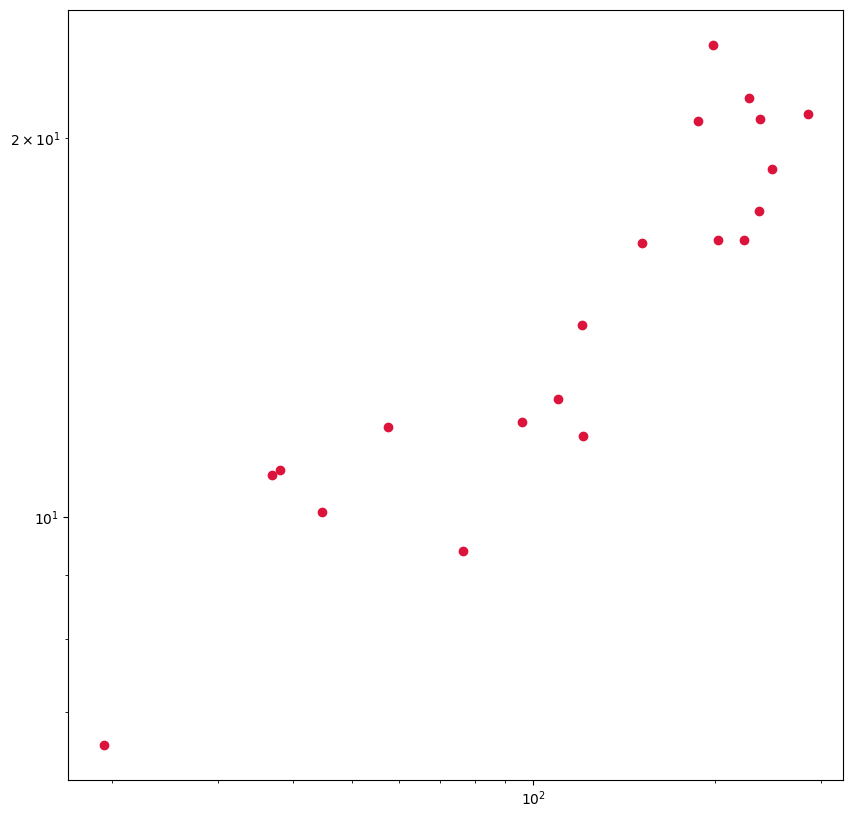

In [54]:
plt.figure(figsize=(10, 10))
plt.scatter(x_test, y_test, color='crimson')
plt.yscale('log')
plt.xscale('log')

